<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Communication Systems
</font>
<hr/>
<font color="#800080" size=5>
Assignment 1
<br>
</font>
<font size=5>
Instructor: Dr. Pakravan
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>

<hr>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @YadollahiAlii
</font>
<br>
<hr>
</div></font>

Name = "Amitis Mirabedini"

StudentId = "402102562"

# Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz
from scipy.fft import fft, ifft, fftshift, fftfreq
from numpy.linalg import pinv
import scipy.stats as stats

# add your libraries

#Question 1

In communication systems, short bursts or transients (like pulses or chirps) are used to probe or transmit through channels.  
We define a causal signal that starts at time \(T_0\), then decays exponentially with oscillations.


$x(t) = (t - T_0)^3 e^{-(t - T_0)/\tau} \cos(2\pi f_0 (t - T_0)) u(t - T_0)$


---

## Task 1.1
1. Generate and plot \(x(t)\) for $(0 \le t \le 100\,s)$ in $0.01$ second increments..  
2. Identify:
   - The time when the signal reaches its maximum amplitude.
   - The approximate pulse duration (where it is non-negligible).
3. Compute and plot the **magnitude spectrum** |X(f)|.  
4. Estimate the **3 dB bandwidth** of the main lobe.

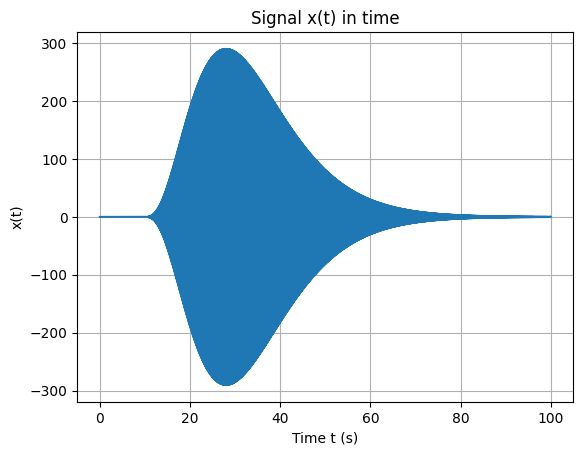

Time of maximum |x(t)|: 28.0 seconds
Maximum value x(t): 290.35818272138255
Approx. pulse starts at: 12.9 s
Approx. pulse ends at: 66.55 s
Approx. pulse duration: 53.65 s


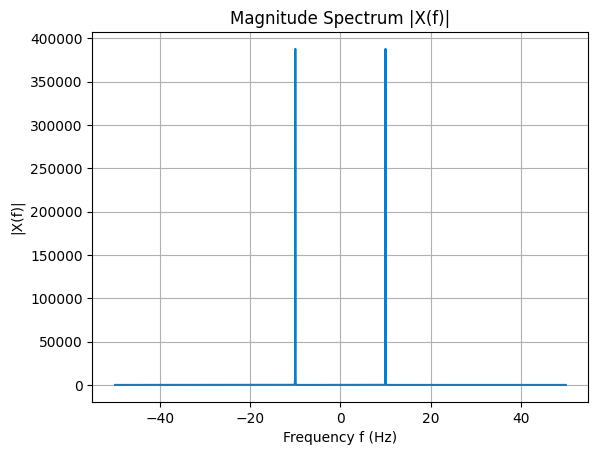

Peak frequency (main lobe): 9.999000099989999 Hz
3 dB left frequency: 9.97900209979002 Hz
3 dB right frequency: 10.01899810018998 Hz
Estimated 3 dB bandwidth: 0.03999600039996132 Hz


In [4]:
# Task 1.1
dt = 0.01
t = np.arange(0, 100 + dt, dt)
T0, f0, tau = 10.0, 10.0, 6.0
u = (t >= T0).astype(float)
tt = t - T0
x = (tt**3) * np.exp(-tt / tau) * np.cos(2 * np.pi * f0 * tt) * u
#1)Plotting x(t)
plt.figure()
plt.plot(t, x)
plt.xlabel('Time t (s)')
plt.ylabel('x(t)')
plt.title('Signal x(t) in time')
plt.grid(True)
plt.show()

#2.1)Max Amplitude(using abs)
x_abs = np.abs(x)
idx_max = np.argmax(x_abs)
t_max = t[idx_max]
x_max = x[idx_max]

print("Time of maximum |x(t)|:", t_max, "seconds")
print("Maximum value x(t):", x_max)

#2.2) Pulse duration (non-negligible -> if the amplitude is bigger than 5% of the max amplitude)
threshold = 0.05 * np.max(x_abs)
indices_nz = np.where(x_abs > threshold)[0]

t_start = t[indices_nz[0]]
t_end = t[indices_nz[-1]]
pulse_duration = t_end - t_start

print("Approx. pulse starts at:", t_start, "s")
print("Approx. pulse ends at:", t_end, "s")
print("Approx. pulse duration:", pulse_duration, "s")

#3)Magnitude Spectrum
N = len(x)
X = fft(x)
f = fftfreq(N, dt)          
X_shifted = fftshift(X)
f_shifted = fftshift(f)
X_mag = np.abs(X_shifted)

plt.figure()
plt.plot(f_shifted, X_mag)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('|X(f)|')
plt.title('Magnitude Spectrum |X(f)|')
plt.grid(True)
plt.show()

#4)3 dB bandwidth of the main lobe 

mask_pos = f_shifted >= 0
f_pos = f_shifted[mask_pos]
X_pos = X_mag[mask_pos]

idx_peak = np.argmax(X_pos)
f_peak = f_pos[idx_peak]
X_peak = X_pos[idx_peak]

level_3dB = X_peak / np.sqrt(2)


left_indices = np.where((f_pos < f_peak) & (X_pos <= level_3dB))[0]
if len(left_indices) > 0:
    f_left_3dB = f_pos[left_indices[-1]]
else:
    f_left_3dB = f_pos[0]


right_indices = np.where((f_pos > f_peak) & (X_pos <= level_3dB))[0]
if len(right_indices) > 0:
    f_right_3dB = f_pos[right_indices[0]]
else:
    f_right_3dB = f_pos[-1]

BW_3dB = f_right_3dB - f_left_3dB

print("Peak frequency (main lobe):", f_peak, "Hz")
print("3 dB left frequency:", f_left_3dB, "Hz")
print("3 dB right frequency:", f_right_3dB, "Hz")
print("Estimated 3 dB bandwidth:", BW_3dB, "Hz")

## Task 1.2

A **frequency-selective channel** affects each frequency component differently.  
Some frequencies may be amplified or attenuated, leading to waveform distortion.

We define:

$
H(f) = [1 + k \cos(2\pi f T_0)] [1 + r e^{-(f - f_c)^2 / (2f_w^2)}] e^{-j2\pi f t_d}, \quad |f|\le B
$

$
H(f) = 0, \quad |f|> B
$

---
1. Implement $H(f)$.  
2. Compute $y(t) = \text{IFFT}(H(f)X(f))$.  
3. Plot $x(t)$ and $y(t)$ together.  
4. Discuss how the channel alters amplitude and timing.


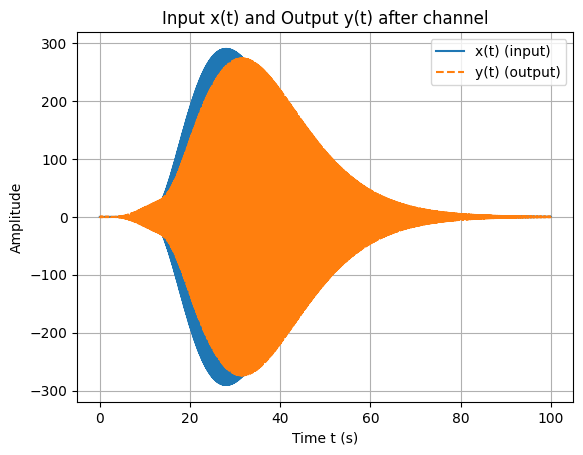

In [5]:
# Task 1.2
k, td, B = 0.35, T0/4, 20.0
r, fc, fw = -0.5, 9.0, 2.0

N = len(x)                  
X = fft(x)                  
f = fftfreq(N, dt)          
#1) H(f) Implementation
H = np.zeros_like(f, dtype=complex)
mask = np.abs(f) <= B
H[mask] = (1 + k * np.cos(2 * np.pi * f[mask] * T0)) * \
          (1 + r * np.exp(-(f[mask] - fc)**2 / (2 * fw**2))) * \
          np.exp(-1j * 2 * np.pi * f[mask] * td)

#2) y(t) computation
Y = H * X 
y = np.real(ifft(Y))

#3) Plotting x(t) and y(t)
plt.figure()
plt.plot(t, x, label='x(t) (input)')
plt.plot(t, y, label='y(t) (output)', linestyle='--')
plt.xlabel('Time t (s)')
plt.ylabel('Amplitude')
plt.title('Input x(t) and Output y(t) after channel')
plt.grid(True)
plt.legend()
plt.show()




Amplitude and Timing Analysis:  
As we can see in the plot y(t) appears later in time than x(t) and it has a smaller peak, the waveform of y(t) looks slightly distorted, because certain frequencies were attenuated more than others.  
The Term (1+ k(cos(2pi* f *T0))) introduces a ripple, this oscillated with frequency and produces predioc gain/attenuation in the spectrum, so different frequency components of X(f) are scaled differently and this causes an amplitude distortion in y(t).  
The term that is consisted of (1 + r * exp(...)) created a notch filter since r = -0.5, this term reduces magnitude arounnf f = 9Hz, so this reduces peak amplitude in time domain in y(t) compared to x(t).  
The exponential term gives the phase response and so by multiplication in the frequency domain it produces a time shift.  


### Checking Amplitude and Time Delay Numerically

In [7]:
print("max x(t):", np.max(np.abs(x)))
print("max y(t):", np.max(np.abs(y)))

idx_x = np.argmax(np.abs(x))
idx_y = np.argmax(np.abs(y))

t_x_max = t[idx_x]
t_y_max = t[idx_y]

print("t_max x(t):", t_x_max)
print("t_max y(t):", t_y_max)
print("Estimated delay (y relative to x):", t_y_max - t_x_max, "seconds")



max x(t): 290.35818272138255
max y(t): 273.9551607190355
t_max x(t): 28.0
t_max y(t): 31.5
Estimated delay (y relative to x): 3.5 seconds


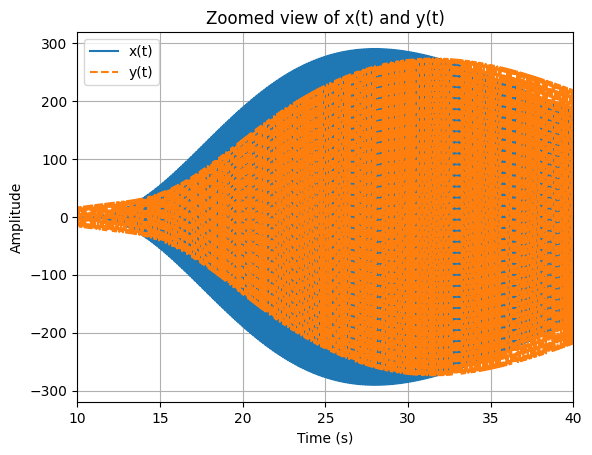

In [ ]:
plt.figure()
plt.plot(t, x, label='x(t)')
plt.plot(t, y, '--', label='y(t)')
plt.xlim(10, 40)      
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Zoomed view of x(t) and y(t)')
plt.grid(True)
plt.legend()
plt.show()


##Task 1.3

The **magnitude** of $H(f)$ shows how frequencies are scaled,  
and the **phase** (or its slope) shows time delay.

The **group delay** is:
$
\tau_g(f) = -\frac{1}{2\pi}\frac{d(\angle H(f))}{df}
$

It measures how much each frequency component is delayed.

---


1. Plot:
   - $|H(f)|$ (in dB)  
   - Phase $ \angle H(f) $ (radians)  
   - Group delay $ \tau_g(f) $
2. Relate group delay trends to observed waveform shifts or smearing.


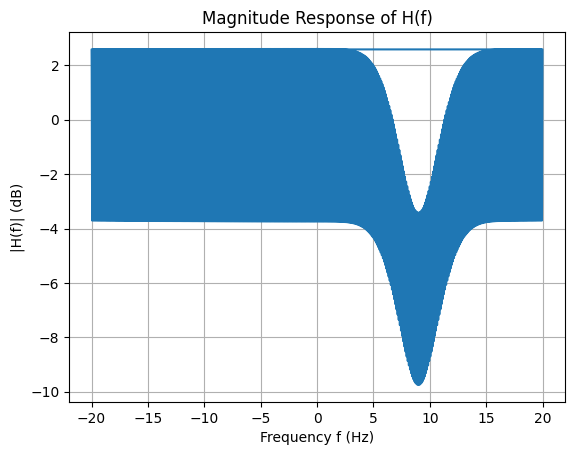

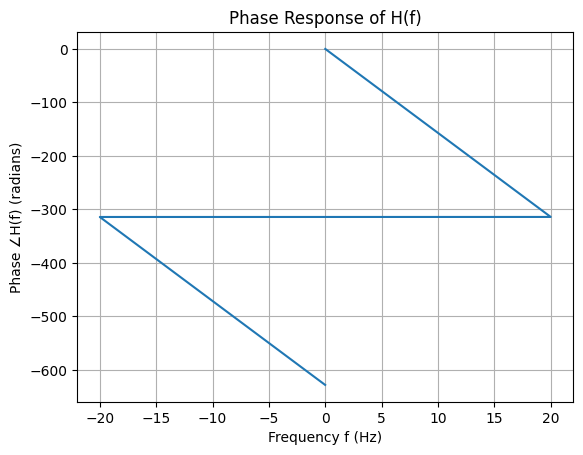

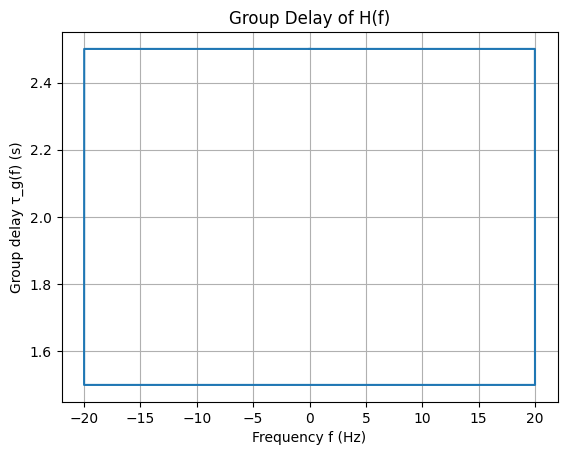

Average group delay in 5–20 Hz band: 2.4993333333333347 s
Theoretical delay t_d = 2.5 s


In [ ]:
# Task 1.3
#1.1) Magnitude in dB
H_mag = np.abs(H)
H_mag_dB = 20 * np.log10(np.maximum(H_mag, 1e-6))
#1.2) Phase 
H_phase = np.angle(H)
H_phase_unwrapped = np.unwrap(H_phase)
#1.3) Group Delay
dphase_df = np.gradient(H_phase_unwrapped, f)   
tau_g = -1.0 / (2 * np.pi) * dphase_df

mask = np.abs(f) <= B
#------------Plotting-------------#
# Magnitude in dB
plt.figure()
plt.plot(f[mask], H_mag_dB[mask])
plt.xlabel('Frequency f (Hz)')
plt.ylabel('|H(f)| (dB)')
plt.title('Magnitude Response of H(f)')
plt.grid(True)
plt.show()

# Phase 
plt.figure()
plt.plot(f[mask], H_phase_unwrapped[mask])
plt.xlabel('Frequency f (Hz)')
plt.ylabel('Phase ∠H(f) (radians)')
plt.title('Phase Response of H(f)')
plt.grid(True)
plt.show()

# Group delay
plt.figure()
plt.plot(f[mask], tau_g[mask])
plt.xlabel('Frequency f (Hz)')
plt.ylabel('Group delay τ_g(f) (s)')
plt.title('Group Delay of H(f)')
plt.grid(True)
plt.show()


band_mask = (f >= 5) & (f <= 20)
avg_tau = np.mean(tau_g[band_mask])
print("Average group delay in 5–20 Hz band:", avg_tau, "s")
print("Theoretical delay t_d =", td, "s")


Because the group delay does not vary significantly with frequency, there is no strong spreading or smearing of the waveform. If the group delay changed rapidly with frequency, different frequency components would arrive at different times, causing the pulse to stretch or blur. Since this does not occur here, the waveform retains its shape and only experiences a delay and amplitude reduction.

## Task 1.4

We now model a feedback-type channel:
$
y[n] - a_1 y[n - d_1] - a_2 y[n - d_2] = x[n]
$

which causes **echoes** or **reverberation**.

---


1. Derive the analytic response:
   $
   H(f) = \frac{1}{1 - a_1 e^{-j2\pi f T_0} - a_2 e^{-j2\pi f (1.5T_0)}}
   $
2. Simulate its impulse response recursively.  
3. Compute and plot both analytic and simulated $|H(f)|$.  
4. Compare and explain differences.


d1 (samples): 1000
d2 (samples): 1500


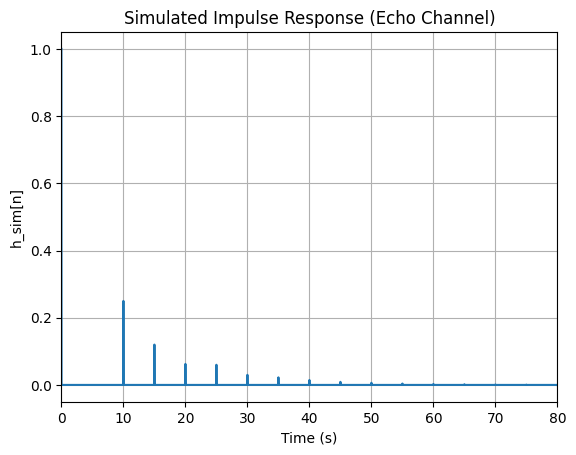

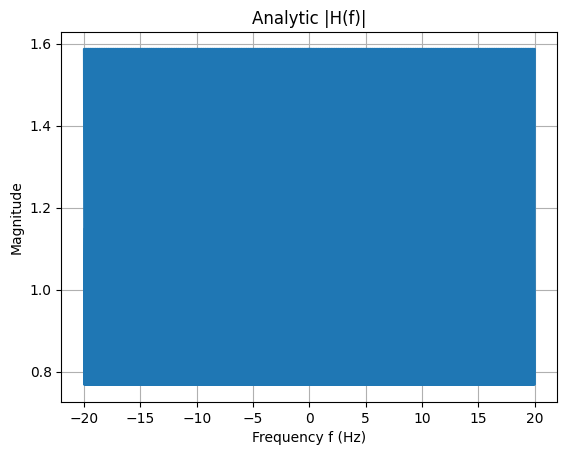

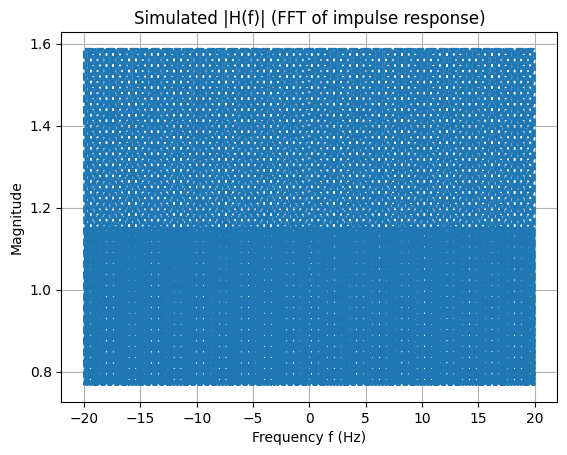

In [16]:
# Task 1.4
a1, a2 = 0.25, 0.12

d1 = int(round(T0 / dt))
d2 = int(round(1.5 * T0 / dt))

print("d1 (samples):", d1)
print("d2 (samples):", d2)
N = len(t)

x_imp = np.zeros(N)
x_imp[0] = 1.0

h_sim = np.zeros(N)

for n in range(N):
    # y[n] = x[n] + a1*y[n-d1] + a2*y[n-d2]
    val = x_imp[n]
    if n - d1 >= 0:
        val += a1 * h_sim[n - d1]
    if n - d2 >= 0:
        val += a2 * h_sim[n - d2]
    h_sim[n] = val

# Plotting impulse respinse too see echos better
plt.figure()
plt.plot(t, h_sim)
plt.xlim(0, 80)
plt.xlabel('Time (s)')
plt.ylabel('h_sim[n]')
plt.title('Simulated Impulse Response (Echo Channel)')
plt.grid(True)
plt.show()


# frequency axis
f = fftfreq(N, dt)

# Analytic H(f)
H_analytic = 1.0 / (1.0
                    - a1 * np.exp(-1j * 2 * np.pi * f * T0)
                    - a2 * np.exp(-1j * 2 * np.pi * f * (1.5 * T0)))

# Simulated H(f) from FFT of impulse response
H_sim = fft(h_sim)

# Magnitudes
H_analytic_mag = np.abs(H_analytic)
H_sim_mag = np.abs(H_sim)

# Plot over some reasonable band, e.g. -20 to 20 Hz
mask = (f >= -20) & (f <= 20)

# Plot analytic |H(f)| separately
plt.figure()
plt.plot(f[mask], H_analytic_mag[mask])
plt.xlabel('Frequency f (Hz)')
plt.ylabel('Magnitude')
plt.title('Analytic |H(f)|')
plt.grid(True)
plt.show()

# Plot simulated |H(f)| separately
plt.figure()
plt.plot(f[mask], H_sim_mag[mask], '--')
plt.xlabel('Frequency f (Hz)')
plt.ylabel('Magnitude')
plt.title('Simulated |H(f)| (FFT of impulse response)')
plt.grid(True)
plt.show()


The analytic magnitude response is smoother because it is computed directly from the closed-form formula assuming infinitely long impulse response, But the simulated response which was obtained from the FFT of the recursive impulse response contains dense oscillations and appears to be noisy. This is mainly becuase the simulated impulse repince is truncated in time(finite duration). 
runcation is equivalent to multiplying the true infinite impulse response by a rectangular window, which in the frequency domain corresponds to convolution with a sinc function, producing oscillatory ripple in the magnitude spectrum.  
Even though the simulated plot appears more oscillatory, the overall envelope of both responses matches, meaning the simulation correctly represents the theoretical channel behavior. The differences are only due to finite-length effects and numerical resolution.


## Task 1.5


In wireless channels, multipath gains vary randomly.  
We let  $a_2 = \beta$  follow a **Rayleigh distribution**, introducing randomness to the channel response.

We want to estimate $E[Y (t)]$. For this, we calculate the output of the channel for N random
occurrences of $β$ and show them as $Y1(t), Y2(t), ..., YN(t)$, then we take the average of these N
output signals and use the following signal as an estimate of $E[Y (t)]$

---

1. Generate multiple random β values (Rayleigh distributed).  
2. Simulate the output $y_i(t)$ for each β.  
3. Plot several outputs and label each curve with its β.  
4. Compute the ensemble mean $E[Y(t)]$ for N = 10, 50, 100, 300 realizations.  
5. Discuss convergence: does $E[Y(t)]$ stabilize as N increases?


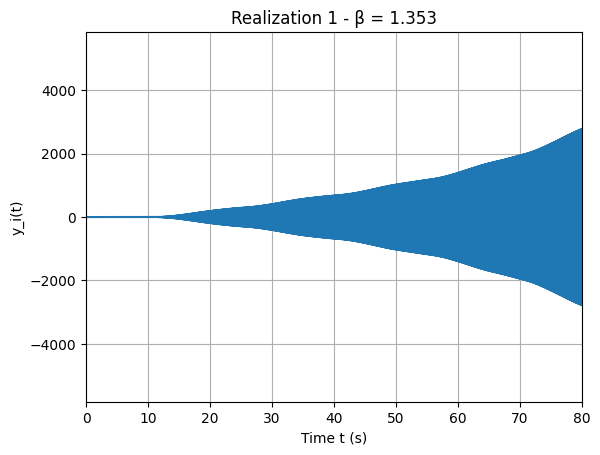

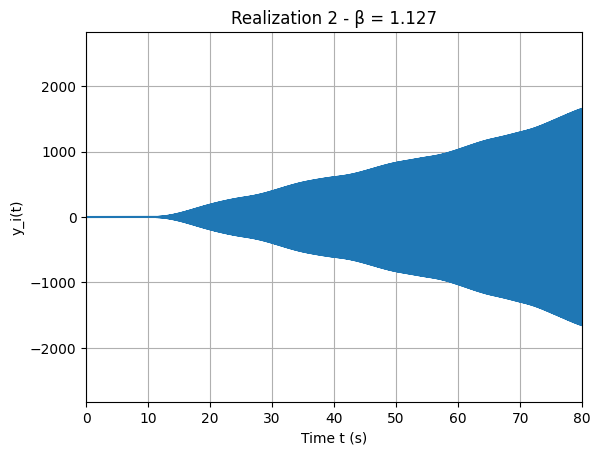

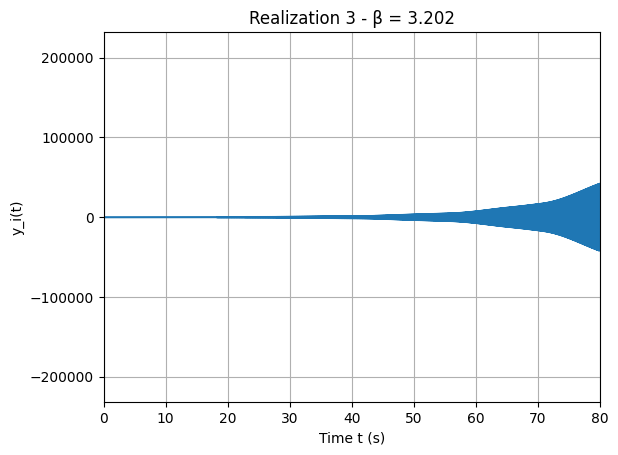

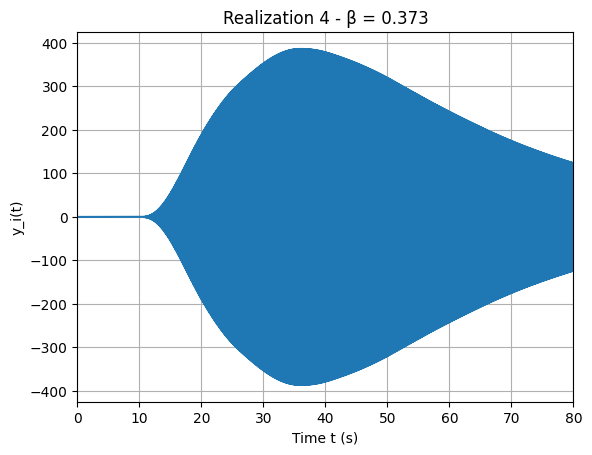

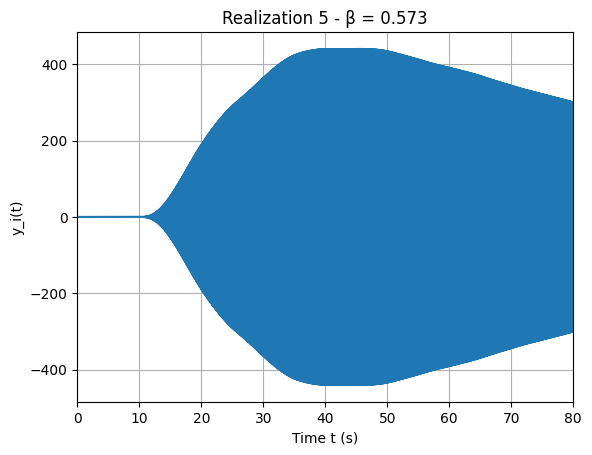

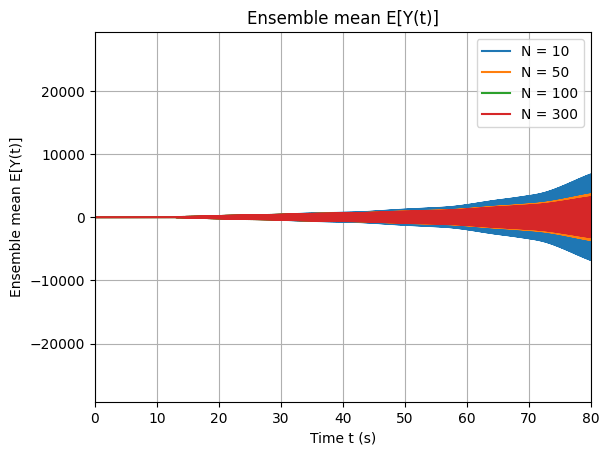

In [14]:
# Task 1.5

sigma = 0.9
def sample_beta():
    return stats.rayleigh(scale=sigma).rvs()

Nsim = 300
ys, betas = [], []

N = len(x)

for i in range(Nsim):
    beta = sample_beta()
    betas.append(beta)
    y = np.zeros_like(x)
    for n in range(N):
        val = x[n]
        if n >= d1:
            val += a1 * y[n - d1]
        if n >= d2:
            val += beta * y[n - d2]
        y[n] = val
    ys.append(y)

ys = np.array(ys)

for i in range(5):
    plt.figure()
    plt.plot(t, ys[i])
    plt.xlim(0, 80)
    plt.xlabel('Time t (s)')
    plt.ylabel('y_i(t)')
    plt.title(f'Realization {i+1} - β = {betas[i]:.3f}')
    plt.grid(True)
    plt.show()

Ns = [10, 50, 100, 300]

plt.figure()
for Ncur in Ns:
    y_mean = np.mean(ys[:Ncur, :], axis=0)
    plt.plot(t, y_mean, label=f'N = {Ncur}')
plt.xlim(0, 80)
plt.xlabel('Time t (s)')
plt.ylabel('Ensemble mean E[Y(t)]')
plt.title('Ensemble mean E[Y(t)]')
plt.grid(True)
plt.legend()
plt.show()


Each realization yi(t) dependes on a random Rayleigh-distributed gain beta, so the individual output signals vary significantly. When calculating the ensemble mean, the average for small N like 10 is unstable and fluctuates because it is influenced by a few random realizations, As we increase the number of realizations to reach 300, these fluctuations become smaller and the ensemble mean becomes more consistent. 
This demonstrates convergence toward the true expected waveform, consistent with the law of large numbers, which states that averaging more samples reduces the effect of randomness. 


#Question 2

As you saw in the previous section, the random channel damages the received signal. In this section, we try to recover the original signal. You have seen in the lesson that the frequency
response of the ideal channel is as follows:

$
H(f) = k e^{-2\pi ft_0}
$

But due to the arrival of the wave from several paths, the channel is in the form of the equation in Task 1.2. In order to recover the exact input signal in the receiver, a equalizer is used in such a way
that the whole system operation can be modeled as an ideal channel.
If we call the frequency response of the equalizer $H_{Eq}(f)$, we have:

$
H_{Eq}(f) H_{Channel}(f) = k e^{-2\pi ft_0}
$

##Task 2.1
1. What is an m-tapped delay line equalizer? Search about its purpose in communication systems and how its structure (including the delay elements, taps, and coefficients) enables it to equalize a received signal.
2. Suppose we replace the value of the random coefficient of $a_2 = \beta$ with $E[β]$. In this case, calculate the frequency response of the equalizer for the channel of Taks 1.3 and show that the equalizer will be an m-tapped delay line equalizer.


### What is an m-tapped delay line equalizer?  
An m-tapped delay line equalizer is a type of Finite Impulse Response (FIR) filter used at the receiver in communication systems to compensate for distortion caused by the channel, such as multipath fading and inter-symbol interference (ISI).

### Purpose in Communication Systems

In wireless channels, a transmitted signal may arrive at the receiver through multiple paths, each with a different delay and gain. This causes overlapping between symbol intervals (ISI), which distorts the received signal and increases error probability.
The goal of the equalizer is to reverse the effect of the channel so that the combined response of channel + equalizer becomes close to an ideal channel (pure delay and scaling), allowing correct signal recovery.

### Structure

The equalizer consists of:  
- A delay line that stores past samples of the received signal.  
- m tap points, each multiplying a delayed sample by an adjustable coefficient ck.
- A summer, which adds the weighted delayed samples.  
This structure enables the equalizer to create a linear combination of different delayed versions of the signal to cancel ISI.  

z[n] =  Σ (from k = 0 to m-1)  ck * r[n - k]

### How does is work?  
- Each delayed version of r[n] represents a copy of the signal arriving over a different multipath component.  
- The coefficients ck are chosen so that the equalizer reinforces useful signal components and cancels infering ones.  
- The equalizer effectively inverts the channel response, so that the cascaded response becomes:  
Heq(f)Hchannel(g) almost equal to k * e ^(-j * 2p * f * t0)  
this means the output is clean, delayed, scaled version of the original trnasmitted signal with minimal dostortion and reduced ISI.







## **2. Equalizer frequency response and m-tapped delay line form**

We start from the feedback-type channel:

$$
y[n] - a_1 y[n-d_1] - a_2 y[n-d_2] = x[n]
$$

Taking the DTFT:

$$
Y(f) - a_1 e^{-j2\pi f d_1 T_s} Y(f) - a_2 e^{-j2\pi f d_2 T_s} Y(f) = X(f)
$$

Factoring out \( Y(f) \):

$$
Y(f)\left[1 - a_1 e^{-j2\pi f d_1 T_s} - a_2 e^{-j2\pi f d_2 T_s}\right] = X(f)
$$

So the channel frequency response is:

$$
H_{ch}(f) = \frac{Y(f)}{X(f)} =
\frac{1}{1 - a_1 e^{-j2\pi f T_0} - a_2 e^{-j2\pi f(1.5T_0)}}
$$

---

### **Replacing \( a_2 = \beta \) by its mean \( E[\beta] \)**

Let:

$$
\bar{a}_2 = E[\beta]
$$

Then the average channel becomes:

$$
H_{ch}(f) =
\frac{1}{1 - a_1 e^{-j2\pi f T_0} - \bar{a}_2 e^{-j2\pi f(1.5T_0)}}
$$

---

### **Equalizer frequency response**

We want:

$$
H_{Eq}(f)\, H_{ch}(f) = k e^{-j2\pi f t_0}
$$

Thus the equalizer is:

$$
H_{Eq}(f) =
\frac{k e^{-j2\pi f t_0}}{H_{ch}(f)}
=
k e^{-j2\pi f t_0}
\left(1 - a_1 e^{-j2\pi f T_0} - \bar{a}_2 e^{-j2\pi f(1.5T_0)}\right)
$$

Expanding:

$$
H_{Eq}(f) =
k e^{-j2\pi f t_0}
- k a_1 e^{-j2\pi f(t_0 + T_0)}
- k \bar{a}_2 e^{-j2\pi f(t_0 + 1.5T_0)}
$$

---

### **Interpretation: m-tapped delay line**

This is a finite sum of delayed exponentials:

$$
H_{Eq}(f) =
C_0 e^{-j2\pi f \tau_0}
+ C_1 e^{-j2\pi f \tau_1}
+ C_2 e^{-j2\pi f \tau_2}
$$

Where:

$$
C_0 = k,\ \tau_0 = t_0
$$

$$
C_1 = -k a_1,\ \tau_1 = t_0 + T_0
$$

$$
C_2 = -k \bar{a}_2,\ \tau_2 = t_0 + 1.5T_0
$$

Using the Fourier property:

$$
\mathcal{F}\{\delta(t-\tau)\} = e^{-j2\pi f \tau}
$$

So in the time domain:

$$
h_{Eq}(t) =
C_0\,\delta(t-\tau_0)
+ C_1\,\delta(t-\tau_1)
+ C_2\,\delta(t-\tau_2)
$$

Discrete-time impulse response:

$$
h_{Eq}[n] =
c_0 \delta[n-n_0]
+ c_1 \delta[n-(n_0+d_1)]
+ c_2 \delta[n-(n_0+d_2)]
$$

Equalizer output:

$$
z[n] =
c_0 r[n-n_0]
+ c_1 r[n-n_0-d_1]
+ c_2 r[n-n_0-d_2]
$$

---

### **Final Conclusion**

Replacing \(a_2 = \beta\) with its mean \(E[\beta]\) converts the equalizer frequency response into a finite sum of delayed exponentials.  
In time domain this becomes a **finite number of delayed impulse taps**, which is exactly the structure of an **m-tapped delay line equalizer (m = 3)**.


##Task 2.2
Now suppose that $x(t)$ which was mentioned in question 1 passes through the following channel:
$
y(t) = x(t) + γ x(t - T_0)
$

where γ = 0.5

In this case, try to neutralize the effect of the channel with the help of a m-Tapped-Delay Line
Equalizer. You may need to use Taylor series. For m = 3, 4, , ..., 10 calculate the coefficients
and the amount of delays.


m = 3
coeffs c_k:        [ 1.   -0.5   0.25]
delays (samples):  [   0 1000 2000]
delays (seconds):  [ 0. 10. 20.]

m = 4
coeffs c_k:        [ 1.    -0.5    0.25  -0.125]
delays (samples):  [   0 1000 2000 3000]
delays (seconds):  [ 0. 10. 20. 30.]

m = 5
coeffs c_k:        [ 1.     -0.5     0.25   -0.125   0.0625]
delays (samples):  [   0 1000 2000 3000 4000]
delays (seconds):  [ 0. 10. 20. 30. 40.]

m = 6
coeffs c_k:        [ 1.      -0.5      0.25    -0.125    0.0625  -0.03125]
delays (samples):  [   0 1000 2000 3000 4000 5000]
delays (seconds):  [ 0. 10. 20. 30. 40. 50.]

m = 7
coeffs c_k:        [ 1.       -0.5       0.25     -0.125     0.0625   -0.03125   0.015625]
delays (samples):  [   0 1000 2000 3000 4000 5000 6000]
delays (seconds):  [ 0. 10. 20. 30. 40. 50. 60.]

m = 8
coeffs c_k:        [ 1.        -0.5        0.25      -0.125      0.0625    -0.03125
  0.015625  -0.0078125]
delays (samples):  [   0 1000 2000 3000 4000 5000 6000 7000]
delays (seconds):  [ 0. 10. 20. 30. 40.

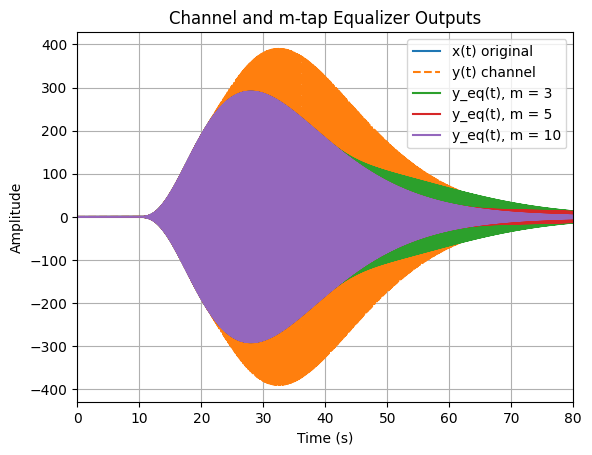

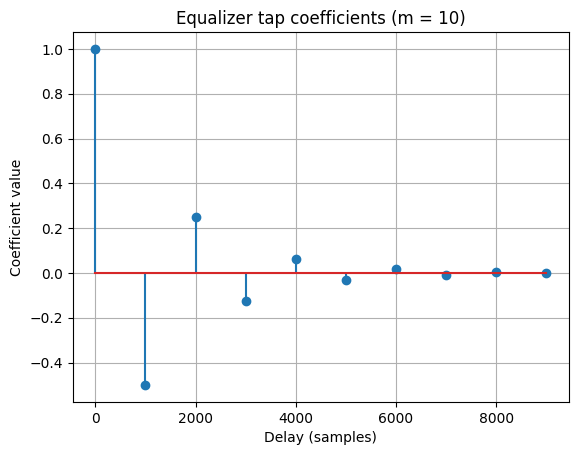

In [21]:
# Task 2.2

dt = 0.01
t = np.arange(0, 100 + dt, dt)
T0, f0, tau = 10.0, 10.0, 6.0

u = (t >= T0).astype(float)
tt = t - T0
x = (tt**3) * np.exp(-tt / tau) * np.cos(2 * np.pi * f0 * tt) * u

gamma = 0.5
d = int(round(T0 / dt))

N = len(x)
y_ch = np.zeros_like(x)
for n in range(N):
    y_ch[n] = x[n]
    if n - d >= 0:
        y_ch[n] += gamma * x[n - d]

def eq_coeffs_and_delays(m):
    ks = np.arange(m)
    coeffs = (-gamma) ** ks
    delays_samples = ks * d
    delays_time = delays_samples * dt
    return coeffs, delays_samples, delays_time

for m in range(3, 11):
    coeffs, d_samp, d_time = eq_coeffs_and_delays(m)
    print(f"\nm = {m}")
    print("coeffs c_k:       ", coeffs)
    print("delays (samples): ", d_samp)
    print("delays (seconds): ", d_time)

ms_to_show = [3, 5, 10]

plt.figure()
plt.plot(t, x, label='x(t) original')
plt.plot(t, y_ch, '--', label='y(t) channel')

for m in ms_to_show:
    coeffs, d_samp, _ = eq_coeffs_and_delays(m)
    y_eq = np.zeros_like(x)
    for n in range(N):
        s = 0.0
        for k in range(m):
            nk = n - d_samp[k]
            if nk >= 0:
                s += coeffs[k] * y_ch[nk]
        y_eq[n] = s
    plt.plot(t, y_eq, label=f'y_eq(t), m = {m}')

plt.xlim(0, 80)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Channel and m-tap Equalizer Outputs')
plt.grid(True)
plt.legend()
plt.show()

m = 10
coeffs_10, d_samp_10, d_time_10 = eq_coeffs_and_delays(m)

plt.figure()
plt.stem(d_samp_10, coeffs_10)  # <-- fixed here
plt.xlabel('Delay (samples)')
plt.ylabel('Coefficient value')
plt.title('Equalizer tap coefficients (m = 10)')
plt.grid(True)
plt.show()


## Task 2.3
Suppose we denote the recovered signal by using m-Tapped-Delay Line Equalizer as  $\hat{x}_m(t)$.

Also, we pass the input signal through the ideal channel and get $\hat{y}(t)$ as the output.

We define the error criterion as follows:
$
RMS Error_m = \int_{-∞}^{∞} |\hat{x}_m(t) - \hat{y}(t)|^2\,dt
$

1. Calculate the error rate for m = 3, 4, ..., 10 and plot its graph. Select the vertical axis once as linear and once as logarithmic.
2. plot $x(t)$ ,$y(t)$ , $\hat{x}_m(t)$ and $\hat{y}(t)$ in a graph and compare them.

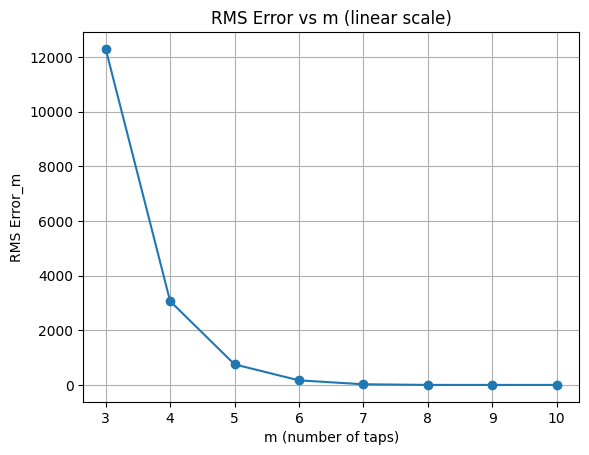

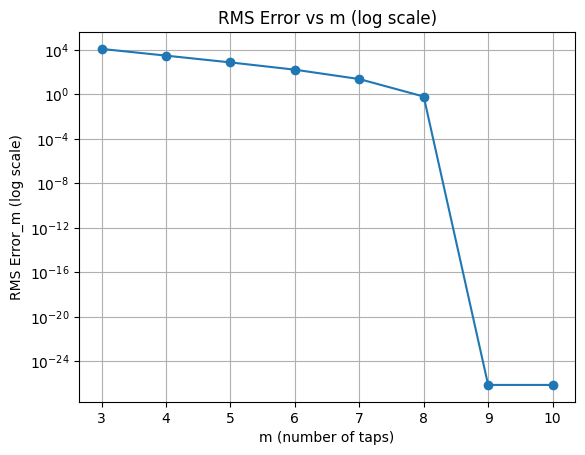

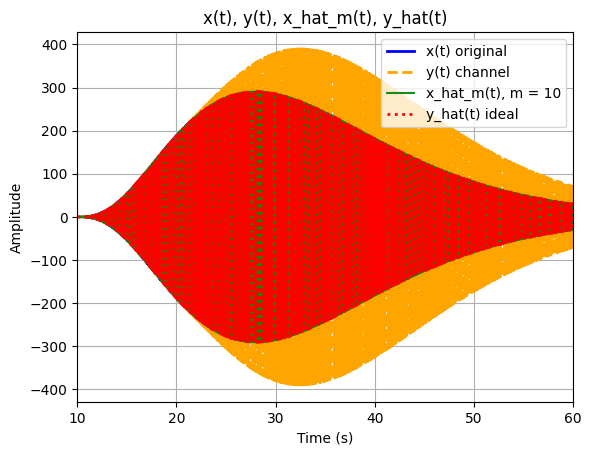

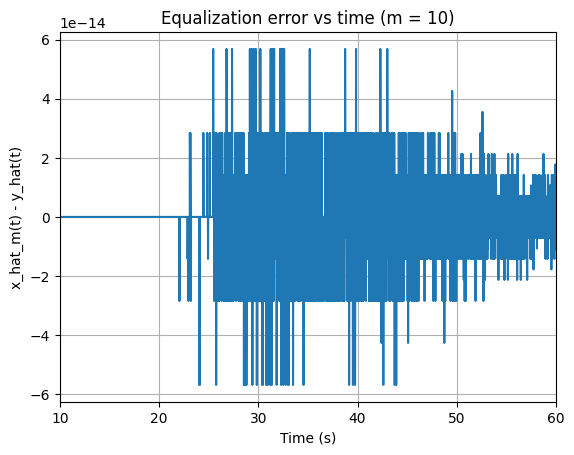

In [25]:
# Task 2.3

y_hat = x.copy()

m_vals = np.arange(3, 11)
errors = []
x_hat_store = {}

for m in m_vals:
    coeffs, d_samp, _ = eq_coeffs_and_delays(m)
    x_hat_m = np.zeros_like(x)
    for n in range(N):
        s = 0.0
        for k in range(m):
            nk = n - d_samp[k]
            if nk >= 0:
                s += coeffs[k] * y_ch[nk]
        x_hat_m[n] = s
    x_hat_store[m] = x_hat_m
    err = np.sum(np.abs(x_hat_m - y_hat) ** 2) * dt
    errors.append(err)

errors = np.array(errors)

plt.figure()
plt.plot(m_vals, errors, marker='o')
plt.xlabel('m (number of taps)')
plt.ylabel('RMS Error_m')
plt.title('RMS Error vs m (linear scale)')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(m_vals, errors, marker='o')
plt.xlabel('m (number of taps)')
plt.ylabel('RMS Error_m (log scale)')
plt.title('RMS Error vs m (log scale)')
plt.yscale('log')
plt.grid(True)
plt.show()

m_plot = 10
x_hat_plot = x_hat_store[m_plot]

plt.figure()
plt.plot(t, x, 'b-', linewidth=2, label='x(t) original')
plt.plot(t, y_ch, color='orange', linestyle='--', linewidth=2, label='y(t) channel')
plt.plot(t, x_hat_plot, 'g-', linewidth=1.5, alpha=0.9, label=f"x_hat_m(t), m = {m_plot}")
plt.plot(t, y_hat, 'r:', linewidth=2, label='y_hat(t) ideal')
plt.xlim(10, 60)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('x(t), y(t), x_hat_m(t), y_hat(t)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, x_hat_plot - y_hat)
plt.xlim(10, 60)
plt.xlabel('Time (s)')
plt.ylabel('x_hat_m(t) - y_hat(t)')
plt.title(f'Equalization error vs time (m = {m_plot})')
plt.grid(True)
plt.show()


On the linear scale, the error decreases rapidly as m increases.  
On the logarithmic scale, the error decreases almost exponentially.  
y(t) is noticeably distorted due to multiple effects. 
 $\hat{x}_m(t)$ almost perfectly overlaps with $\hat{y}(t)$ and the original x(t).  

The equalizer successfully removes the echo effect. As m increases, the recovered signal becomes closer to the ideal signal, and for m = 10
, the equalization is essentially perfect. The very small residual error is attributable only to machine rounding effects, not to actual signal distortion.
